## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [130]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [131]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000026131B19490> [0]

In [132]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [133]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2024_filled_mean_rain.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [134]:
timeline_file.head()

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-01,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,13838.000000,13694.000000,0.003767,1,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,0.003767,0.003767,0.003767,0.003767
1,1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-02,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14096.000000,13800.000000,1.743561,2,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,1.747329,1.747329,1.747329,1.747329
2,2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-03,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14096.000000,13868.000000,3.378342,3,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.125671,5.125671,5.125671,5.125671
3,3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-04,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14291.000000,14023.000000,0.130370,4,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.256042,5.256042,5.256042,5.256042
4,4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-05,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,13922.000000,14023.000000,0.000000,5,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.256042,5.256042,5.256042,5.256042


In [135]:
timeline_file.shape

(158515, 38)

In [136]:
# wnv_file.head()

In [137]:
# wnv_file.shape

In [138]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [139]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [140]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [141]:
# dataset_list = []
# groups = timeline_file.groupby(['x', 'y', 'year'])

# for group, data in groups:
#     temp_df = data.copy()
#     temp_df.reset_index(drop=True, inplace=True)
#     temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
#     temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
#     temp_df['acc_rainfall_month'] = temp_df['rainfall'].rolling(window=30, min_periods=0).sum()
#     temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
#     dataset_list.append(temp_df)

# dataset = pd.concat(dataset_list, ignore_index=True)
# dataset.reset_index(drop=True, inplace=True)

In [142]:
dataset = timeline_file.copy()

In [143]:
dataset.dtypes

Unnamed: 0                     int64
NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
rainfall                     float64
day                            int64
lst_jan_day_mean             float64
l

In [144]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [145]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [146]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [147]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [148]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<Axes: >

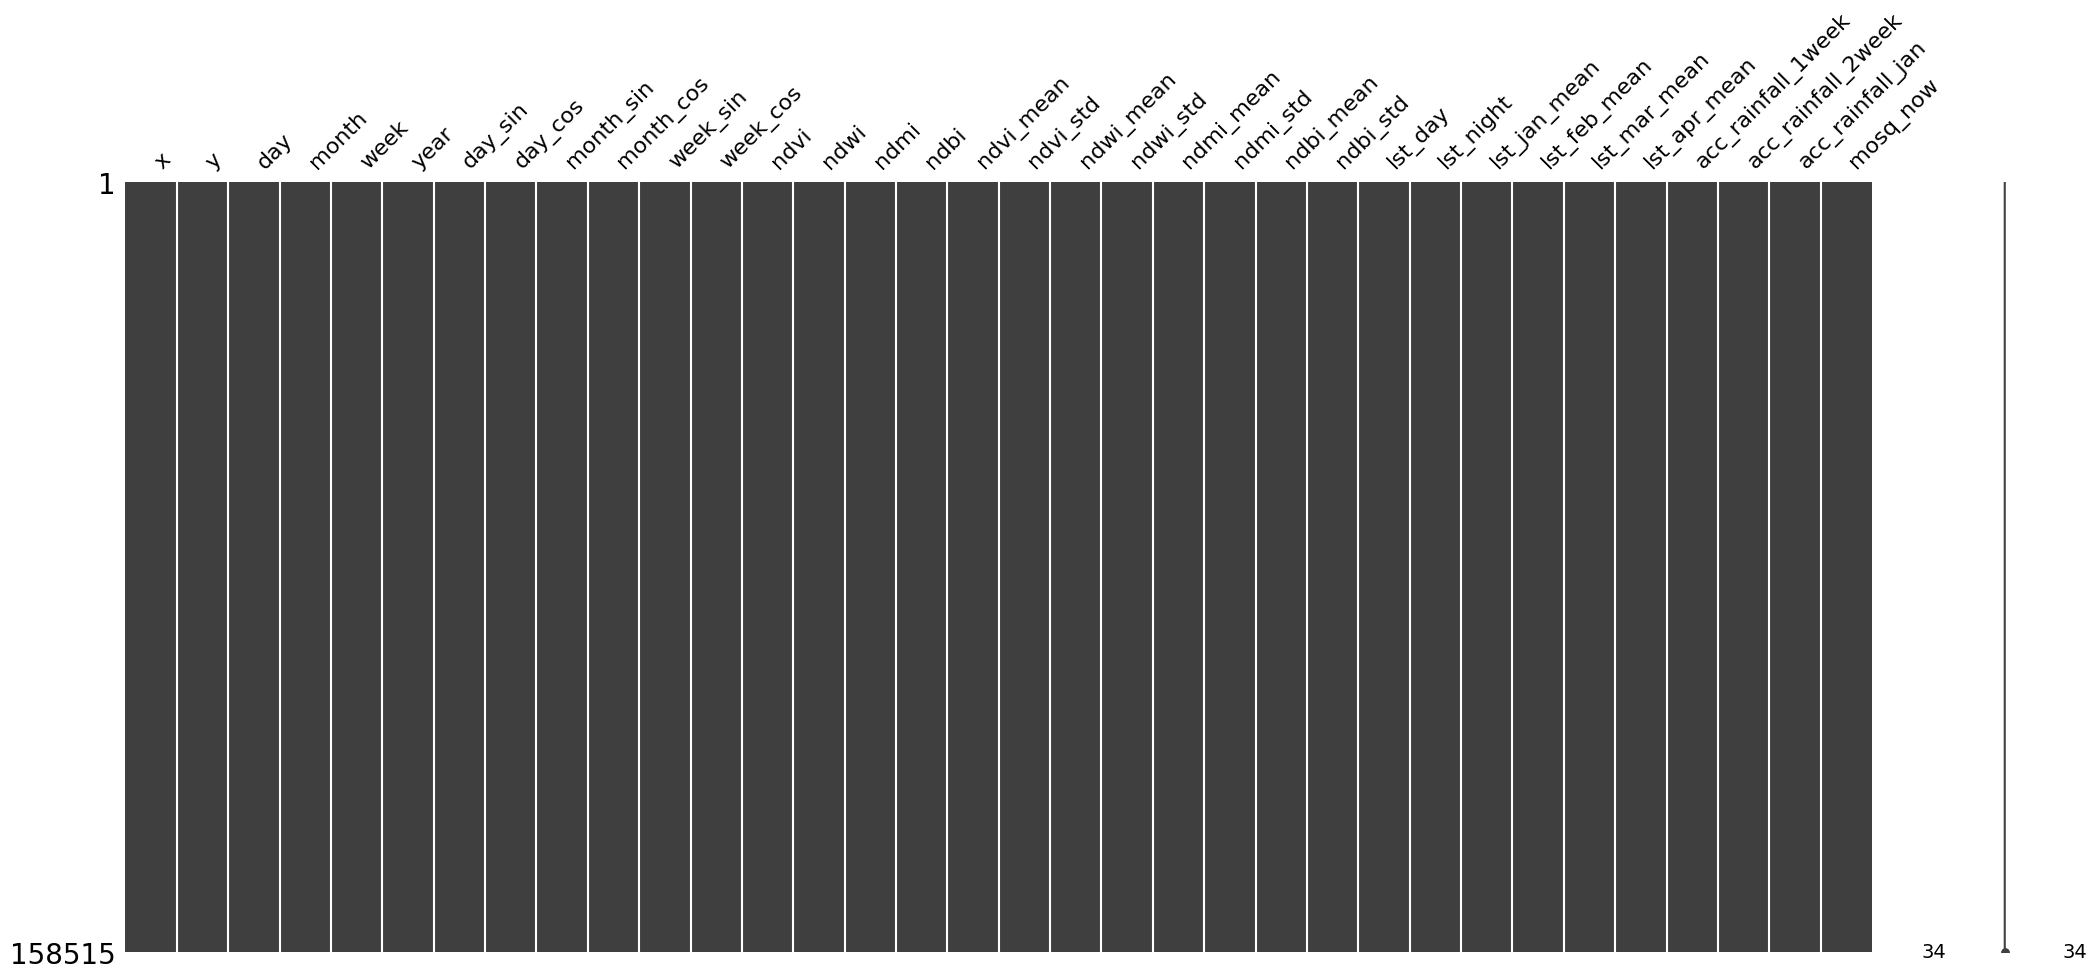

In [149]:
missingno.matrix(dataset_mamoth)

In [150]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [151]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [152]:
predictions = give_predictions(model, dataset_mamoth)

In [153]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.784690,40.821750,2024-01-01,45
1,21.784690,40.821750,2024-01-02,42
2,21.784690,40.821750,2024-01-03,44
3,21.784690,40.821750,2024-01-04,43
4,21.784690,40.821750,2024-01-05,49
...,...,...,...,...
158510,24.070040,40.980230,2024-07-28,36
158511,24.070040,40.980230,2024-07-29,28
158512,24.070040,40.980230,2024-07-30,29
158513,24.070040,40.980230,2024-07-31,26


<Axes: >

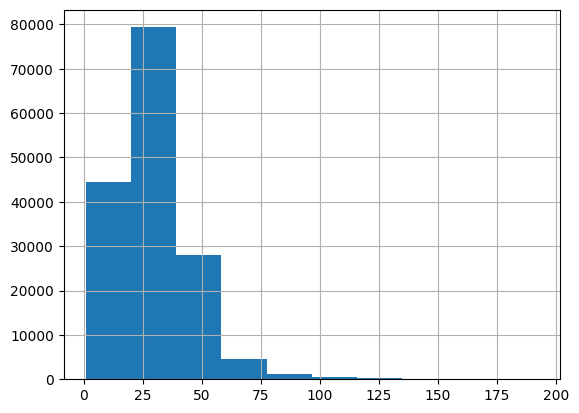

In [154]:
mosqutio_predictions.mosq_pred.hist()

In [155]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2024.csv", encoding = enc, index = False)

# mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
# mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

#dataset = timeline_file

In [156]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [157]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-01,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,13838.000000,13694.000000,0.003767,1,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,0.003767,0.003767,0.003767,0.003767,13766.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,45
1,1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-02,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14096.000000,13800.000000,1.743561,2,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,1.747329,1.747329,1.747329,1.747329,13948.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,42
2,2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-03,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14096.000000,13868.000000,3.378342,3,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.125671,5.125671,5.125671,5.125671,13982.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,44
3,3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-04,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14291.000000,14023.000000,0.130370,4,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.256042,5.256042,5.256042,5.256042,14157.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,43
4,4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-05,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,13922.000000,14023.000000,0.000000,5,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.256042,5.256042,5.256042,5.256042,13972.500000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198624,158512,EL52,κεντρικη μακεδονια,EL526,σερρες,24.070040,40.980230,2024-07-30,2024,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15591.000000,14773.000000,NaN,30,14007.569260,13679.173730,14328.537751,13822.389678,14462.719798,13952.830276,14947.914248,14226.913987,0.000000,0.000000,0.000000,273.645107,15182.000000,13843.371495,14075.463714,14207.775037,14587.414118,31,-0.201299,0.979530,-0.500000,-0.866025,-0.508531,-0.861044,29
198625,158513,EL52,κεντρικη μακεδονια,EL526,σερρες,24.070040,40.980230,2024-07-31,2024,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15254.000000,14784.000000,NaN,31,14007.569260,13679.173730,14328.537751,13822.389678,14462.719798,13952.830276,14947.914248,14226.913987,0.000000,0.000000,0.000000,273.645107,15019.000000,13843.371495,14075.4

In [158]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [159]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [160]:
dataset_locations

,x,y
0,21.784690,40.821750
1,21.837970,40.781330
2,21.837970,40.821750
3,21.837970,40.862180
4,21.837970,40.943030
...,...,...
642,23.963310,41.061080
643,24.016670,40.939800
644,24.016670,40.980230
645,24.016670,41.020650


In [161]:
dataset_locations_per_year

,x,y,year
0,21.784690,40.821750,2024
1,21.837970,40.781330,2024
2,21.837970,40.821750,2024
3,21.837970,40.862180,2024
4,21.837970,40.943030,2024
...,...,...,...
642,23.963310,41.061080,2024
643,24.016670,40.939800,2024
644,24.016670,40.980230,2024
645,24.016670,41.020650,2024


In [162]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [163]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0


In [164]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_18876\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [165]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.784690,40.821750,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587
1,21.837970,40.781330,370.133349,736.789061,4,210.148125,547.932181,186.708704,1.104109,1.350092
2,21.837970,40.821750,3484.337851,360.011750,2,166.943095,572.913987,182.738469,0.000000,42.019621
3,21.837970,40.862180,7086.442119,1550.130722,12,182.666887,883.195007,186.639914,0.000000,1.517649
4,21.837970,40.943030,15573.536731,2363.349856,21,75.995366,1684.205242,128.211168,0.000000,1.621208
...,...,...,...,...,...,...,...,...,...,...
642,23.963310,41.061080,26781.583314,2514.243083,5,73.671079,248.544828,170.467815,0.000000,1.854353
643,24.016670,40.939800,20214.640227,901.014934,19,239.387426,403.315487,195.459344,0.000000,9.406274
644,24.016670,40.980230,24051.946169,525.766057,7,170.942009,197.092138,180.263212,0.000000,1.413881
645,24.016670,41.020650,28082.877422,307.150711,8,183.021018,105.868893,180.541604,0.000000,2314.497071


In [166]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [167]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [168]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [169]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.784690,40.821750,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587
1,21.837970,40.781330,370.133349,736.789061,4,210.148125,547.932181,186.708704,1.104109,1.350092
2,21.837970,40.821750,3484.337851,360.011750,2,166.943095,572.913987,182.738469,0.000000,42.019621
3,21.837970,40.862180,7086.442119,1550.130722,12,182.666887,883.195007,186.639914,0.000000,1.517649
4,21.837970,40.943030,15573.536731,2363.349856,21,75.995366,1684.205242,128.211168,0.000000,1.621208
...,...,...,...,...,...,...,...,...,...,...
642,23.963310,41.061080,26781.583314,2514.243083,5,73.671079,248.544828,170.467815,0.000000,1.854353
643,24.016670,40.939800,20214.640227,901.014934,19,239.387426,403.315487,195.459344,0.000000,9.406274
644,24.016670,40.980230,24051.946169,525.766057,7,170.942009,197.092138,180.263212,0.000000,1.413881
645,24.016670,41.020650,28082.877422,307.150711,8,183.021018,105.868893,180.541604,0.000000,2314.497071


In [170]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [171]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [172]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [173]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [174]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [175]:
landcover_2024 = landcover_2023 = landcover_2022

In [176]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 0.0
Max distance: 0.0


In [177]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [178]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.784690,40.821750,2024,31,86.000000,30,86.000000,30,86.000000,10,10,1,6,6,2,0
1,21.837970,40.781330,2024,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
2,21.837970,40.821750,2024,31,95.000000,36,96.000000,30,95.000000,12,12,3,5,8,2,0
3,21.837970,40.862180,2024,31,95.000000,36,89.000000,30,95.000000,12,12,3,5,8,2,0
4,21.837970,40.943030,2024,31,94.000000,30,94.000000,30,94.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,23.963310,41.061080,2024,31,95.000000,36,95.000000,30,95.000000,12,12,3,5,8,2,0
643,24.016670,40.939800,2024,22,73.000000,20,73.000000,20,73.000000,9,9,4,1,1,2,0
644,24.016670,40.980230,2024,31,96.000000,36,96.000000,30,96.000000,12,12,3,5,8,2,0
645,24.016670,41.020650,2024,31,98.000000,36,98.000000,30,98.000000,12,12,3,5,8,2,0


In [179]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [180]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [181]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [182]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-01,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,13838.000000,13694.000000,0.003767,1,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,0.003767,0.003767,0.003767,0.003767,13766.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,45,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587,31,86.000000,30,86.000000,30,86.000000,10,10,1,6,6,2,0
1,1,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-02,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14096.000000,13800.000000,1.743561,2,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,1.747329,1.747329,1.747329,1.747329,13948.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,42,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587,31,86.000000,30,86.000000,30,86.000000,10,10,1,6,6,2,0
2,2,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-03,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14096.000000,13868.000000,3.378342,3,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.125671,5.125671,5.125671,5.125671,13982.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,44,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587,31,86.000000,30,86.000000,30,86.000000,10,10,1,6,6,2,0
3,3,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-04,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,14291.000000,14023.000000,0.130370,4,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.256042,5.256042,5.256042,5.256042,14157.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,43,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587,31,86.000000,30,86.000000,30,86.000000,10,10,1,6,6,2,0
4,4,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.821750,2024-01-05,2024,1,0.353924,-0.084399,-0.357775,0.084399,0.346883,-0.063754,-0.352691,0.063754,0.029716,0.050295,0.021779,0.050295,13922.000000,14023.000000,0.000000,5,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,5.256042,5.256042,5.256042,5.256042,13972.500000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,49,1735.698065,1818.434438,6,116.561177,723.374161,146.865934,0.000000,5.909587,31,86.000000,30,86.000000,30,86.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [183]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [184]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [185]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [186]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [187]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [188]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,5145,22.173780,40.605260,2024,1,-0.024550,-0.128664,-0.428345,-0.605809,0.033237,-0.111152,-0.369811,-0.633708,0.000000,0.000000,0.000000,0.000000,14055.000000,13683.000000,0.141359,1,14032.290323,13746.152927,14255.954023,13831.109974,14438.946237,13940.183393,14919.331852,14193.684444,0.141359,0.141359,0.141359,0.141359,13833.500000,13889.221625,14043.531999,14189.564815,14556.508148,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,38,430.952681,91.643222,2,53.475540,2.926239,142.953571,0.000000,1.000000,31,99.000000,36,99.000000,30,99.000000,12,12,1,6,4,2,0
1,2024-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,52185,23.047450,40.693950,2024,1,-0.336806,-0.207158,-0.496059,-0.639485,-0.252301,-0.203188,-0.462125,-0.514380,0.000000,0.000000,0.000000,0.000000,14168.000000,13826.000000,0.000000,1,14090.169103,13752.431452,14318.711746,13847.003233,14455.550403,13969.115423,14920.507812,14205.187500,0.000000,0.000000,0.000000,0.000000,13971.000000,13921.300277,14082.857489,14212.332913,14562.847656,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,33,0.000000,27.527920,2,0.000000,-0.110060,166.990069,0.000000,1.000000,31,99.000000,36,99.000000,30,99.000000,12,12,1,6,6,2,0
2,2024-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,33320,22.812230,41.014080,2024,1,0.043902,-0.241578,-0.400102,-0.167804,0.123288,-0.218302,-0.359390,-0.035827,0.009470,0.011252,0.012686,0.011252,14069.000000,13783.000000,0.000000,1,14080.964937,13687.890252,14366.282984,13803.943028,14486.357994,13939.163043,14931.026087,14188.704348,0.000000,0.000000,0.000000,0.000000,13916.000000,13884.427595,14085.113006,14212.760519,14559.865217,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,30,838.981974,55.964179,2,51.972498,21.046828,155.354599,0.000000,1.000000,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
3,2024-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,0,21.997790,40.821750,2024,1,0.015101,-0.160811,-0.484950,-0.863882,0.115291,-0.162650,-0.447380,-0.647403,0.017169,0.015794,0.011711,0.015794,14100.000000,13750.000000,0.017526,1,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,0.017526,0.017526,0.017526,0.017526,13766.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,41,370.133349,8.811430,3,39.371894,0.345523,128.211168,0.000000,1.000000,31,97.000000,20,86.000000,20,86.000000,12,9,4,4,4,2,0
4,2024-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,24255,22.499840,40.249300,2024,1,-0.097713,-0.171845,-0.493800,-0.631579,0.049185,-0.110478,-0.471209,-0.572256,0.021288,0.016123,0.016307,0.016123,14182.000000,13877.000000,0.042586,1,14115.173477,13811.256631,14328.963985,13899.536398,14430.055914,13972.210036,14784.741333,14219.517333,0.042586,0.042586,0.042586,0.042586,14023.500000,13963.215054,14114.250192,14201.132975,14502.129333,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,36,2954.704953,0.550164,3,69.909220,6.318075,133.905980,0.000000,1.000000,31,98.000000,36,98.000000,30,98.000000,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [189]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,5145,21.961760,40.403140,2024,1,-0.024550,-0.128664,-0.428345,-0.605809,0.033237,-0.111152,-0.369811,-0.633708,0.000000,0.000000,0.000000,0.000000,13847.000000,13590.000000,0.020516,1,14032.290323,13746.152927,14255.954023,13831.109974,14438.946237,13940.183393,14919.331852,14193.684444,0.020516,0.020516,0.020516,0.020516,13765.000000,13889.221625,14043.531999,14189.564815,14556.508148,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,23,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,11,68.000000,10,65.000000,10,65.000000,1,1,1,1,1,2,0
1,2024-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,52185,22.623090,40.410970,2024,1,-0.336806,-0.207158,-0.496059,-0.639485,-0.252301,-0.203188,-0.462125,-0.514380,0.000000,0.000000,0.000000,0.000000,13761.000000,13339.000000,0.000000,1,14090.169103,13752.431452,14318.711746,13847.003233,14455.550403,13969.115423,14920.507812,14205.187500,0.000000,0.000000,0.000000,0.000000,13750.000000,13921.300277,14082.857489,14212.332913,14562.847656,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,10,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,3,67.000000,3,67.000000,3,54.000000,1,0,0,0,0,1,0
2,2024-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,33320,22.385070,40.852380,2024,1,0.043902,-0.241578,-0.400102,-0.167804,0.123288,-0.218302,-0.359390,-0.035827,0.009470,0.011252,0.012686,0.011252,13929.000000,13519.000000,0.000000,1,14080.964937,13687.890252,14366.282984,13803.943028,14486.357994,13939.163043,14931.026087,14188.704348,0.000000,0.000000,0.000000,0.000000,13772.500000,13884.427595,14085.113006,14212.760519,14559.865217,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,24,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,14,70.000000,10,70.000000,10,70.000000,4,4,1,4,4,2,0
3,2024-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,0,21.784690,40.700480,2024,1,0.015101,-0.160811,-0.484950,-0.863882,0.115291,-0.162650,-0.447380,-0.647403,0.017169,0.015794,0.011711,0.015794,13806.000000,13523.000000,0.003767,1,14030.537757,13718.344941,14263.298981,13823.321708,14447.520894,13936.327947,14900.916364,14208.900909,0.003767,0.003767,0.003767,0.003767,13710.000000,13874.441349,14043.310345,14191.924421,14554.908636,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,22,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,14,67.000000,10,67.000000,10,62.000000,4,4,1,2,2,2,0
4,2024-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,24255,22.236190,40.006750,2024,1,-0.097713,-0.171845,-0.493800,-0.631579,0.049185,-0.110478,-0.471209,-0.572256,0.021288,0.016123,0.016307,0.016123,13796.000000,13574.000000,0.042586,1,14115.173477,13811.256631,14328.963985,13899.536398,14430.055914,13972.210036,14784.741333,14219.517333,0.042586,0.042586,0.042586,0.042586,13748.500000,13963.215054,14114.250192,14201.132975,14502.129333,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,26,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,11,70.000000,10,67.000000,10,70.000000,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...

In [190]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean','lst_night','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_nuts3_mean[['rainfall','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan', 'mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [191]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2024-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2024,1,0.280172,0.044434,-0.233778,-0.044434,0.271678,0.044239,-0.229856,-0.044239,0.051211,0.053234,0.052810,0.053234,14040.111111,14032.290323,14255.954023,14438.946237,14919.331852,13765.592593,13746.152927,13831.109974,13940.183393,14193.684444,13902.851852,13889.221625,14043.531999,14189.564815,14556.508148,0.875739,0.875739,0.875739,0.875739,0.875739,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2
1,2024-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2024,1,0.287030,0.025519,-0.246216,-0.025519,0.273545,0.027115,-0.235908,-0.027115,0.059743,0.065514,0.050953,0.065514,14150.304688,14090.169103,14318.711746,14455.550403,14920.507812,13837.804688,13752.431452,13847.003233,13969.115423,14205.187500,13994.054688,13921.300277,14082.857489,14212.332913,14562.847656,0.230099,0.230099,0.230099,0.230099,0.230099,32.414062,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2
2,2024-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2024,1,0.233921,-0.115847,-0.242274,0.115847,0.232337,-0.115375,-0.241180,0.115375,0.042348,0.039870,0.041189,0.039870,14082.293478,14080.964937,14366.282984,14486.357994,14931.026087,13749.695652,13687.890252,13803.943028,13939.163043,14188.704348,13915.994565,13884.427595,14085.113006,14212.760519,14559.865217,0.037097,0.037097,0.037097,0.037097,0.037097,31.663043,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2
3,2024-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2024,1,0.322119,-0.002754,-0.283961,0.002754,0.319643,0.002847,-0.277569,-0.002847,0.061419,0.061304,0.070436,0.061304,14032.511364,14030.537757,14263.298981,14447.520894,14900.916364,13766.215909,13718.344941,13823.321708,13936.327947,14208.900909,13899.363636,13874.441349,14043.310345,14191.924421,14554.908636,0.846134,0.846134,0.846134,0.846134,0.846134,37.181818,17697.

<Axes: >

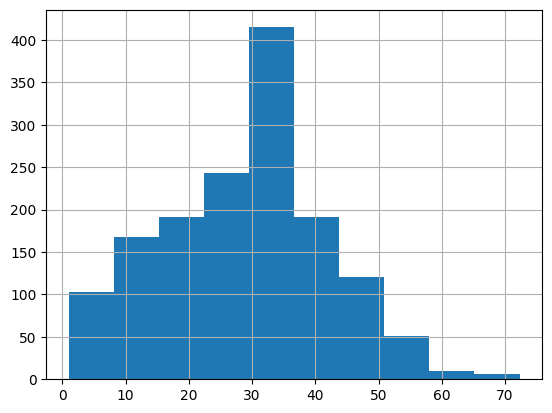

In [192]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [193]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<Axes: >

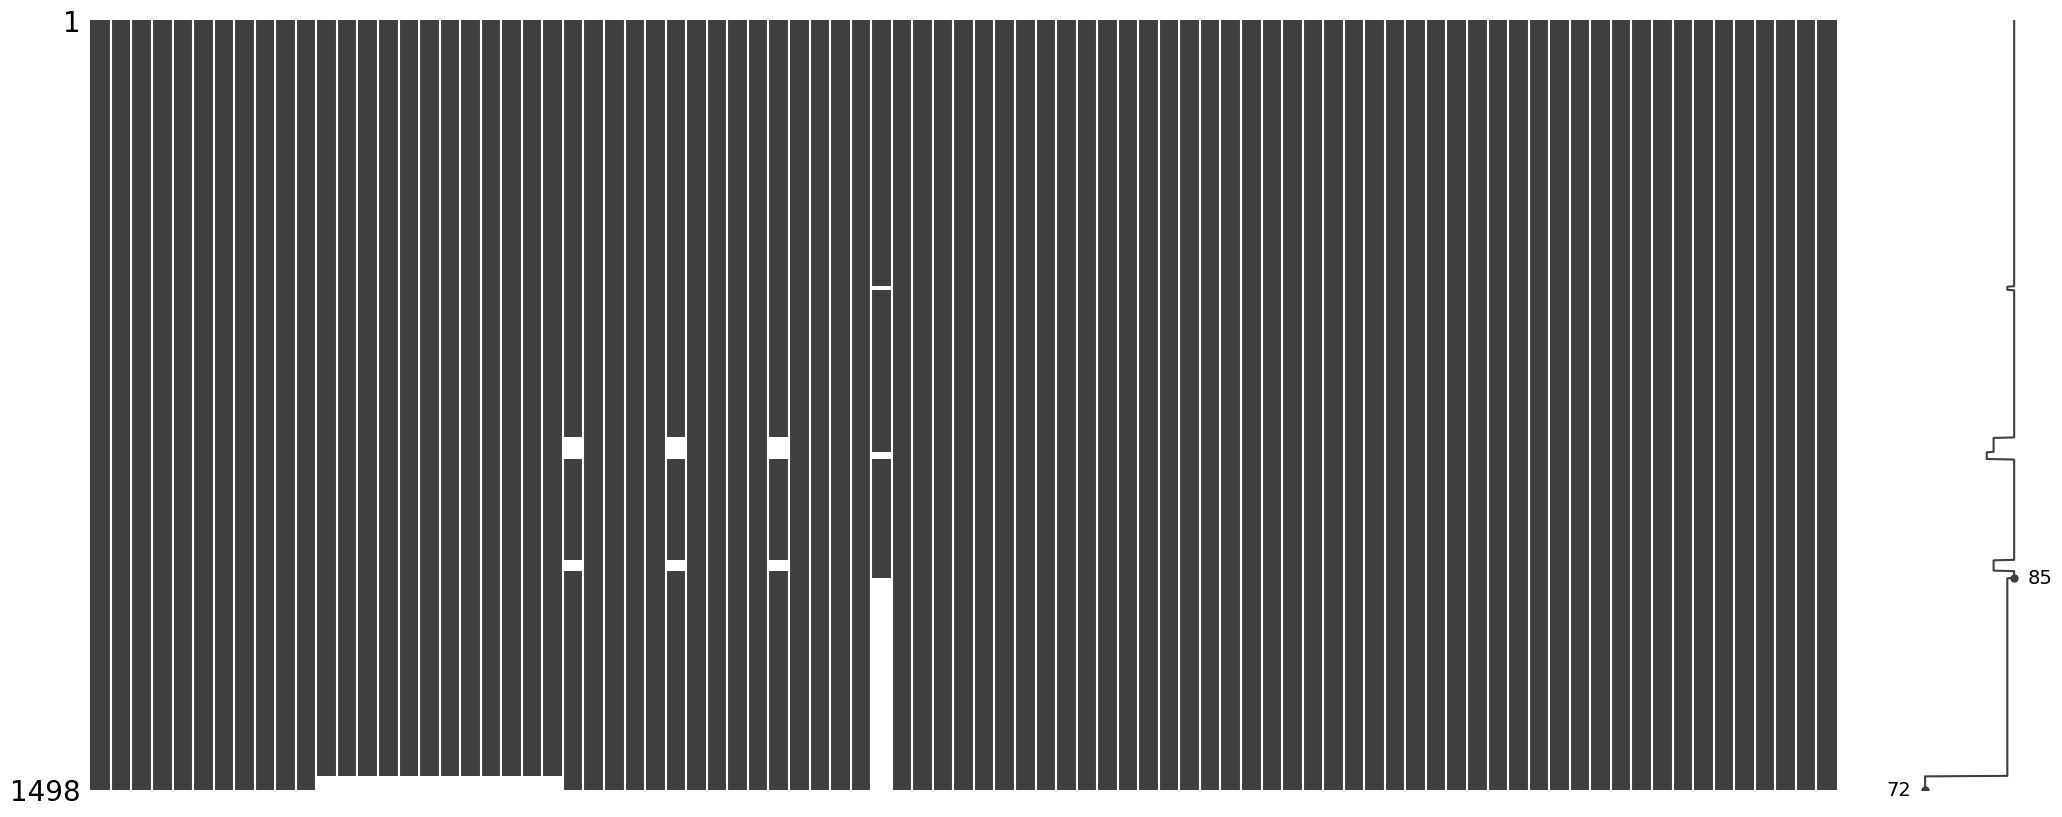

In [194]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [195]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [196]:
bio_values_df = pd.DataFrame(bio_values)

In [197]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,ημαθια,2024,1,-3.513704,11.138148,44.695487
1,ημαθια,2024,2,-3.569623,14.615556,62.057963
2,ημαθια,2024,3,2.542222,24.482593,61.877570
3,ημαθια,2024,4,7.056667,29.077778,106.430496
4,ημαθια,2024,5,9.638519,28.158148,73.616798
5,ημαθια,2024,6,14.810370,34.907778,0.000000
6,ημαθια,2024,7,19.941111,37.131111,0.000000
7,ημαθια,2024,8,19.941111,30.734444,0.000000
8,θεσσαλονικη,2024,1,-3.208750,14.712188,86.334587
9,θεσσαλονικη,2024,2,-3.208750,17.989844,66.792644


In [198]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [199]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2024,1,0.280172,0.044434,-0.233778,-0.044434,0.271678,0.044239,-0.229856,-0.044239,0.051211,0.053234,0.052810,0.053234,7.652222,7.495806,11.969080,15.628925,25.236637,2.161852,1.773059,3.472199,5.653668,10.723689,4.907037,4.634432,7.720640,10.641296,17.980163,0.875739,0.875739,0.875739,0.875739,0.875739,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487
1,2024-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2024,1,0.287030,0.025519,-0.246216,-0.025519,0.273545,0.027115,-0.235908,-0.027115,0.059743,0.065514,0.050953,0.065514,9.856094,8.653382,13.224235,15.961008,25.260156,3.606094,1.898629,3.790065,6.232308,10.953750,6.731094,5.276006,8.507150,11.096658,18.106953,0.230099,0.230099,0.230099,0.230099,0.230099,32.414062,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587
2,2024-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2024,1,0.233921,-0.115847,-0.242274,0.115847,0.232337,-0.115375,-0.241180,0.115375,0.042348,0.039870,0.041189,0.039870,8.495870,8.469299,14.175660,16.577160,25.470522,1.843913,0.607805,2.928861,5.633261,10.624087,5.169891,4.538552,8.552260,11.105210,18.047304,0.037097,0.037097,0.037097,0.037097,0.037097,31.663043,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-3.997391,14.061739,50.160892
3,2024-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2024,1,0.322119,-0.002754,-0.283961,0.002754,0.319643,0.002847,-0.277569,-0.002847,0.061419,0.061304,0.070436,0.061304,7.500227,7.460755,12.115980,15.800418,24.868327,2.174318,1.216899,3.316434,5.576559,11.028018,4.837273,4.338827,7.716207,10.688488,17.948173,0.846134,0.846134,0.846134,0.846134,0.846134,37.181818,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007

<Axes: >

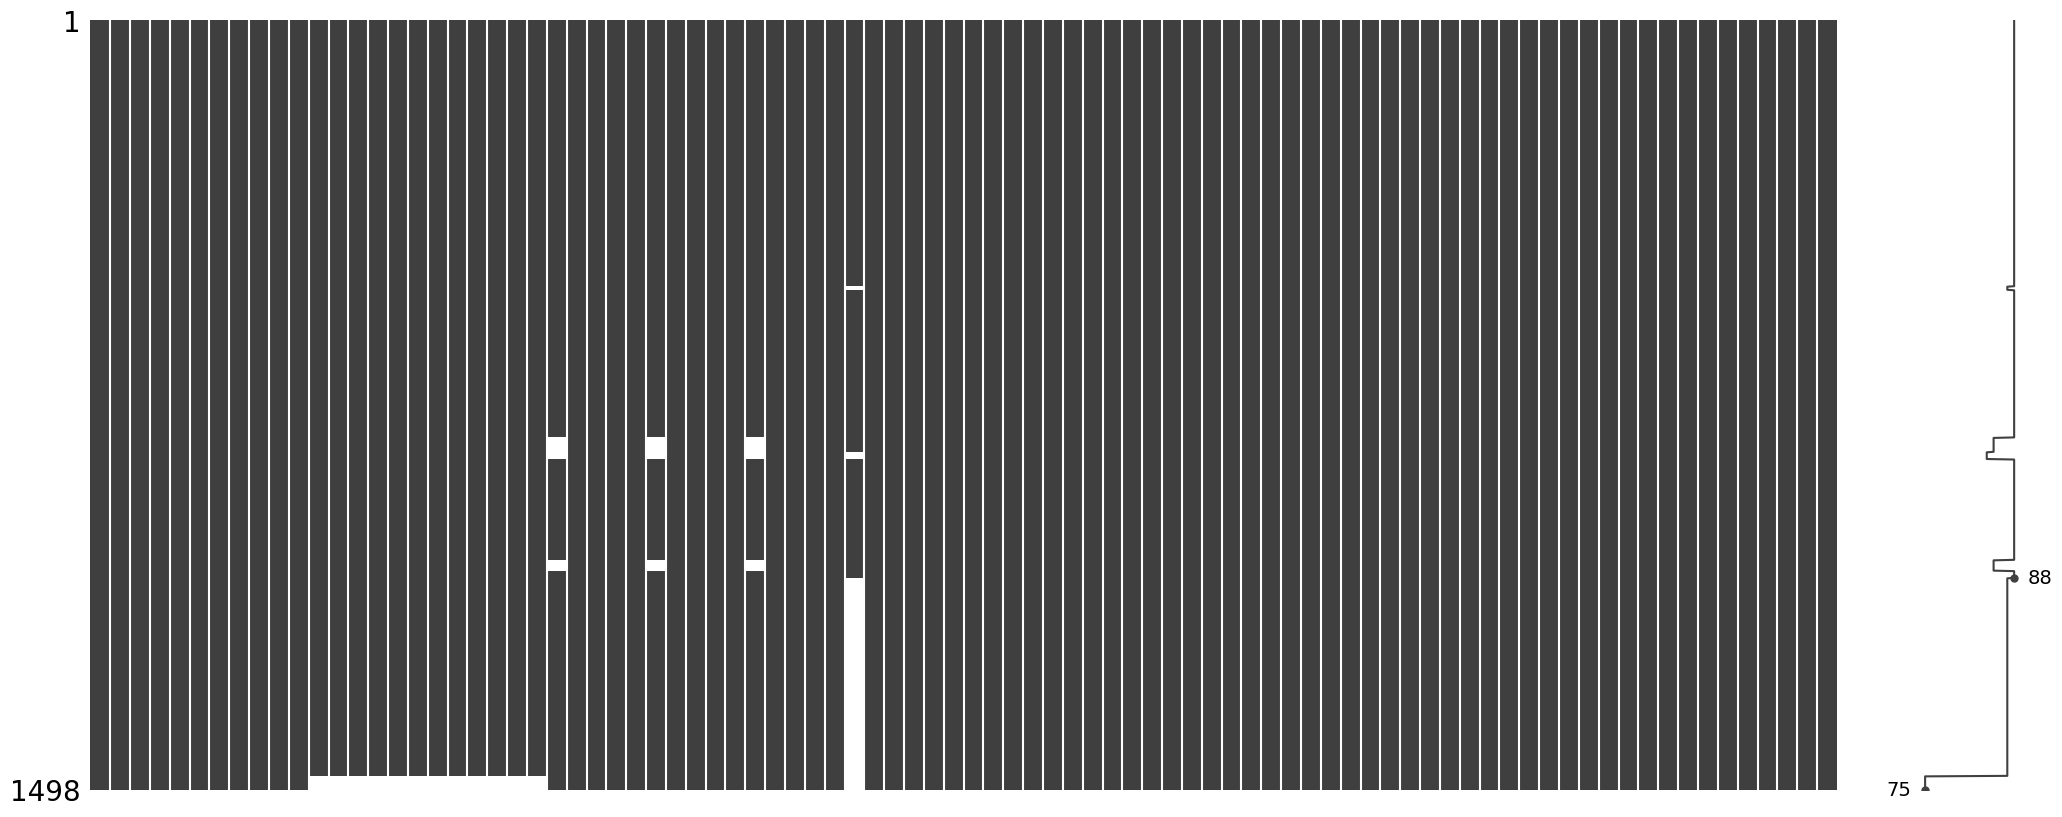

In [200]:
missingno.matrix(dataset)

In [201]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [202]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [203]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2024-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2024,1,0.280172,0.044434,-0.233778,-0.044434,0.271678,0.044239,-0.229856,-0.044239,0.051211,0.053234,0.052810,0.053234,7.652222,7.495806,11.969080,15.628925,25.236637,2.161852,1.773059,3.472199,5.653668,10.723689,4.907037,4.634432,7.720640,10.641296,17.980163,0.875739,0.875739,0.875739,0.875739,0.875739,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487,2024-01
1,2024-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2024,1,0.287030,0.025519,-0.246216,-0.025519,0.273545,0.027115,-0.235908,-0.027115,0.059743,0.065514,0.050953,0.065514,9.856094,8.653382,13.224235,15.961008,25.260156,3.606094,1.898629,3.790065,6.232308,10.953750,6.731094,5.276006,8.507150,11.096658,18.106953,0.230099,0.230099,0.230099,0.230099,0.230099,32.414062,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587,2024-01
2,2024-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2024,1,0.233921,-0.115847,-0.242274,0.115847,0.232337,-0.115375,-0.241180,0.115375,0.042348,0.039870,0.041189,0.039870,8.495870,8.469299,14.175660,16.577160,25.470522,1.843913,0.607805,2.928861,5.633261,10.624087,5.169891,4.538552,8.552260,11.105210,18.047304,0.037097,0.037097,0.037097,0.037097,0.037097,31.663043,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-3.997391,14.061739,50.160892,2024-01
3,2024-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2024,1,0.322119,-0.002754,-0.283961,0.002754,0.319643,0.002847,-0.277569,-0.002847,0.061419,0.061304,0.070436,0.061304,7.500227,7.460755,12.115980,15.800418,24.868327,2.174318,1.216899,3.316434,5.576559,11.028018,4.837273,4.338827,7.716207,10.688488,17.948173,0.846134,0.846134,0.846134,0.846134,0.846134,37.181818,17697.449346,1077.933680,9.795455,157.29

In [204]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2024-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2024,1,0.280172,0.044434,-0.233778,-0.044434,0.271678,0.044239,-0.229856,-0.044239,0.051211,0.053234,0.052810,0.053234,9.850741,7.495806,11.969080,15.628925,25.236637,5.453704,1.773059,3.472199,5.653668,10.723689,7.908704,4.634432,7.720640,10.641296,17.980163,0.000000,0.875739,0.875739,42.744218,42.744218,36.185185,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487
1,1,2024-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2024,1,0.287030,0.025519,-0.246216,-0.025519,0.273545,0.027115,-0.235908,-0.027115,0.059743,0.065514,0.050953,0.065514,9.856094,8.653382,13.224235,15.961008,25.260156,6.892969,1.898629,3.790065,6.232308,10.953750,8.594141,5.276006,8.507150,11.096658,18.106953,0.000000,2.223011,52.638564,52.638564,52.638564,8.062500,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587
2,2,2024-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2024,1,0.233921,-0.115847,-0.242274,0.115847,0.232337,-0.115375,-0.241180,0.115375,0.042348,0.039870,0.041189,0.039870,8.495870,8.469299,14.175660,16.577160,25.470522,-3.997391,0.607805,2.928861,5.633261,10.624087,7.872609,4.538552,8.552260,11.105210,18.047304,0.000000,2.149916,35.737461,48.010977,48.010977,15.184783,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-3.997391,14.061739,50.160892
3,3,2024-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2024,1,0.322119,-0.002754,-0.283961,0.002754,0.319643,0.002847,-0.277569,-0.002847,0.061419,0.061304,0.070436,0.061304,10.761591,7.460755,12.115980,15.800418,24.868327,7.168864,1.216899,3.316434,5.576559,11.028018,8.965227,4.338827,7.716207,10.688488,17.948173,0.000000,0.846134,26.820192,26.820192,37.908247,29.318182,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.

In [205]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [206]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2024,0.253521,0.125124,-0.212388,-0.125124,0.245415,0.125427,-0.206581,-0.125427,0.050790,0.053745,0.052142,0.053745,7.495806,1.773059,4.634432,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,1.441790,7.228771,16.927973,43.819748,44.695487,1071.666667,34.569892,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487
1,2024-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2024,0.306417,0.063853,-0.265244,-0.063853,0.295632,0.060910,-0.256860,-0.060910,0.063070,0.069262,0.053936,0.069262,8.653382,1.898629,5.276006,8.653382,13.224235,15.961008,25.260156,1.898629,3.790065,6.232308,10.953750,5.276006,8.507150,11.096658,18.106953,2.784987,2.093208,27.402839,86.104488,86.334587,738.210938,23.813256,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587
2,2024-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2024,0.238070,-0.066854,-0.245603,0.066854,0.234567,-0.063794,-0.242235,0.063794,0.041735,0.044693,0.039558,0.044693,8.469299,0.607805,4.538552,8.469299,14.175660,16.577160,25.470522,0.607805,2.928861,5.633261,10.624087,4.538552,8.552260,11.105210,18.047304,1.618093,1.951708,10.855320,50.123795,50.160892,828.554348,26.727560,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-3.997391,14.061739,50.160892
3,2024-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2024,0.310052,0.042392,-0.277104,-0.042392,0.305580,0.048101,-0.269530,-0.048101,0.058543,0.062164,0.064466,0.062164,7.460755,1.216899,4.338827,7.460755,12.115980,15.800418,24.868327,1.216899,3.316434,5.576559,11.028018,4.338827,7.716207,10.688488,17.948173,1.222847,4.353534,7.335679,37.062113,37.908247,1097.022727,35.387830,17697.449346,1077.933680

In [207]:
# wnv_file.head(5)

In [208]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            56 non-null     period[M]
 1   NUTS2_ID                56 non-null     object   
 2   NUTS2_NAME              56 non-null     object   
 3   NUTS3_ID                56 non-null     object   
 4   NUTS3_NAME              56 non-null     object   
 5   x                       56 non-null     float64  
 6   y                       56 non-null     float64  
 7   month                   56 non-null     int64    
 8   year                    56 non-null     int64    
 9   ndvi                    49 non-null     float64  
 10  ndmi                    49 non-null     float64  
 11  ndwi                    49 non-null     float64  
 12  ndbi                    49 non-null     float64  
 13  ndvi_mean               49 non-null     float64  
 14  ndmi_mean   

In [209]:
# wnv_file.info()

In [210]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [211]:
# wnv_file

In [212]:
# wnv_file['cases'].value_counts()

In [213]:
# wnv_file.cases.sum()

In [214]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )
merged = grouped_by_month_dataset.copy()

In [215]:
merged['cases'] = 0

In [216]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2024-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2024,0.253521,0.125124,-0.212388,-0.125124,0.245415,0.125427,-0.206581,-0.125427,0.050790,0.053745,0.052142,0.053745,7.495806,1.773059,4.634432,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,1.441790,7.228771,16.927973,43.819748,44.695487,1071.666667,34.569892,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487,0
1,2024-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2024,0.306417,0.063853,-0.265244,-0.063853,0.295632,0.060910,-0.256860,-0.060910,0.063070,0.069262,0.053936,0.069262,8.653382,1.898629,5.276006,8.653382,13.224235,15.961008,25.260156,1.898629,3.790065,6.232308,10.953750,5.276006,8.507150,11.096658,18.106953,2.784987,2.093208,27.402839,86.104488,86.334587,738.210938,23.813256,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587,0
2,2024-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2024,0.238070,-0.066854,-0.245603,0.066854,0.234567,-0.063794,-0.242235,0.063794,0.041735,0.044693,0.039558,0.044693,8.469299,0.607805,4.538552,8.469299,14.175660,16.577160,25.470522,0.607805,2.928861,5.633261,10.624087,4.538552,8.552260,11.105210,18.047304,1.618093,1.951708,10.855320,50.123795,50.160892,828.554348,26.727560,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-3.997391,14.061739,50.160892,0
3,2024-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2024,0.310052,0.042392,-0.277104,-0.042392,0.305580,0.048101,-0.269530,-0.048101,0.058543,0.062164,0.064466,0.062164,7.460755,1.216899,4.338827,7.460755,12.115980,15.800418,24.868327,1.216899,3.316434,5.576559,11.028018,4.338827,7.716207,10.688488,17.948173,1.222847,4.353534,7.335679,37.062113,37.908247,1097.022727,35.387830,17697.449346

In [217]:
merged = fillna(merged,{'cases': 0})

In [218]:
merged['cases'].value_counts()

cases
0    56
Name: count, dtype: int64

In [219]:
merged.cases.sum()

0

In [220]:
merged = merged.astype({'cases': 'int'})

<Axes: >

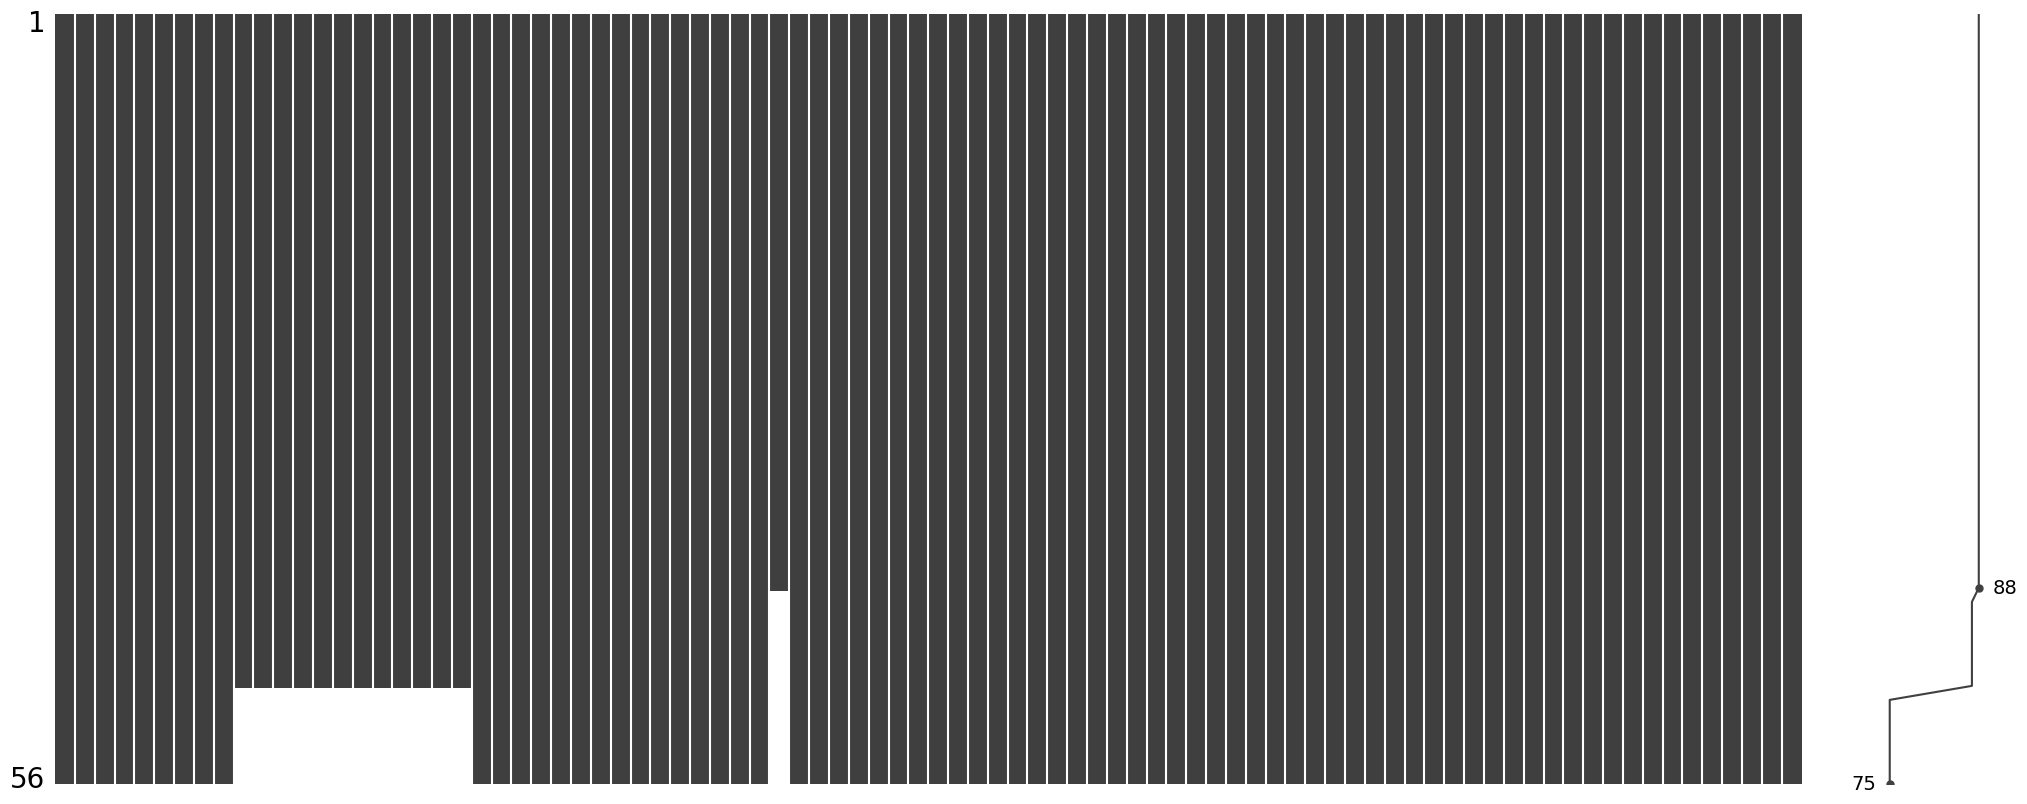

In [221]:
missingno.matrix(merged)

In [222]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

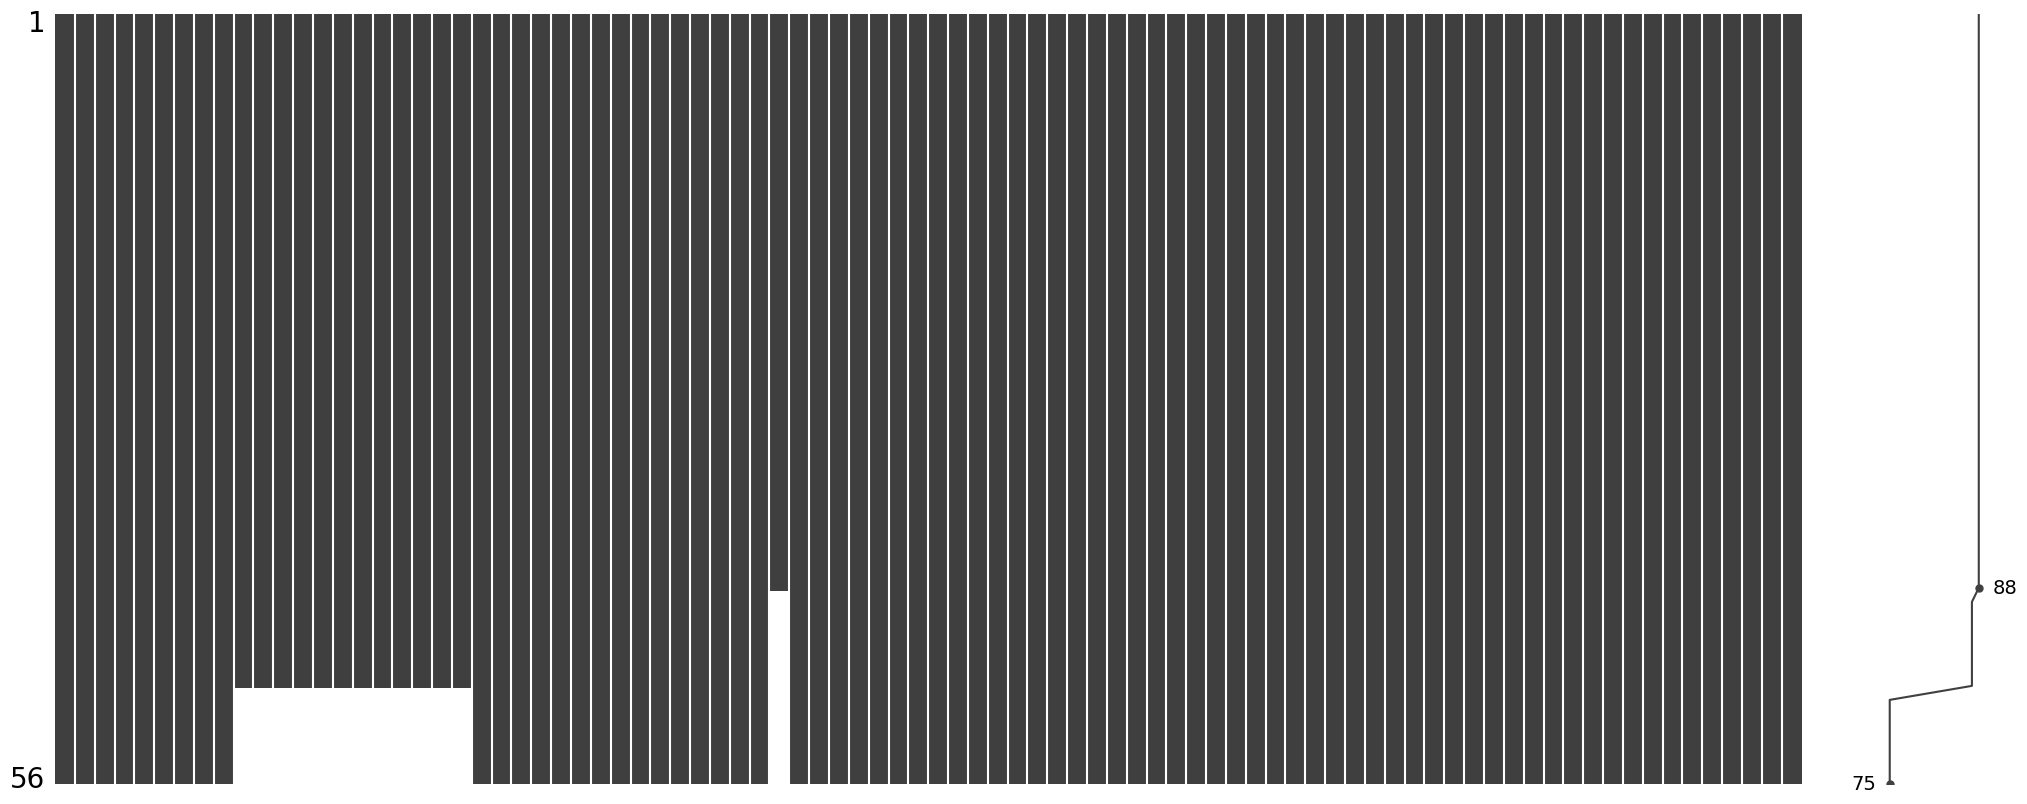

In [223]:
missingno.matrix(merged)

In [224]:
years = merged.year.unique()
years

array([2024], dtype=int64)

In [225]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['ημαθια', 'θεσσαλονικη', 'κιλκις', 'πελλα', 'πιερια', 'σερρες',
       'χαλκιδικη'], dtype=object)

In [226]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [227]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,ημαθια,2024,16.937500,17.875000,44.687500,883.757198,37.000000,-3.000000,40.000000,16.500000,25.500000,25.500000,7.500000,346.000000,106.000000,0.000000,89.997104,240.000000,0.000000,0.000000,167.000000
1,θεσσαλονικη,2024,18.500000,20.250000,46.022727,960.654539,41.000000,-3.000000,44.000000,12.166667,28.500000,28.500000,8.500000,451.000000,149.000000,0.000000,93.111415,300.000000,0.000000,0.000000,237.000000
2,κιλκις,2024,18.812500,21.625000,45.052083,997.116378,45.000000,-3.000000,48.000000,16.666667,29.333333,29.333333,8.666667,358.000000,119.000000,0.000000,95.037990,266.000000,0.000000,0.000000,169.000000
3,πελλα,2024,17.000000,17.750000,42.261905,924.275778,38.000000,-4.000000,42.000000,16.166667,26.166667,26.166667,7.333333,323.000000,90.000000,0.000000,90.423002,239.000000,0.000000,0.000000,153.000000
4,πιερια,2024,17.750000,18.000000,43.902439,926.205778,39.000000,-2.000000,41.000000,11.666667,27.500000,27.500000,8.166667,384.000000,103.000000,0.000000,86.233331,260.000000,0.000000,0.000000,211.000000
5,σερρες,2024,18.437500,19.375000,44.034091,994.426432,41.000000,-3.000000,44.000000,17.500000,28.333333,28.333333,8.000000,279.000000,73.000000,0.000000,92.009439,193.000000,0.000000,0.000000,152.000000
6,χαλκιδικη,2024,18.375000,18.750000,46.875000,865.097022,39.000000,-1.000000,40.000000,16.500000,27.500000,27.500000,9.333333,646.000000,184.000000,0.000000,94.274102,408.000000,0.000000,0.000000,394.000000


In [228]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [229]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2024,0.253521,0.125124,-0.212388,-0.125124,0.245415,0.125427,-0.206581,-0.125427,0.050790,0.053745,0.052142,0.053745,7.495806,1.773059,4.634432,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,1.441790,7.228771,16.927973,43.819748,44.695487,1071.666667,34.569892,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487,0,16.937500,17.875000,44.687500,883.757198,37.000000,-3.000000,40.000000,16.500000,25.500000,25.500000,7.500000,346.000000,106.000000,0.000000,89.997104,240.000000,0.000000,0.000000,167.000000
7,2024-02,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,2,2024,0.292824,0.043295,-0.264495,-0.043295,0.287149,0.040187,-0.261490,-0.040187,0.053904,0.060149,0.055277,0.060149,11.969080,3.464820,7.716950,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,2.139930,38.232360,39.411789,62.080929,106.753450,949.592593,32.744572,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.569623,14.615556,62.057963,0,16.937500,17.875000,44.687500,883.757198,37.000000,-3.000000,40.000000,16.500000,25.500000,25.500000,7.500000,346.000000,106.000000,0.000000,89.997104,240.000000,0.000000,0.000000,167.000000
14,2024-03,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,3,2024,0.355882,0.046847,-0.323609,-0.046847,0.347185,0.052269,-0.316643,-0.052269,0.055621,0.054572,0.048340,0.054572,15.628925,5.653668,10.641296,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,2.062586,4.785008,7.397458,43.094737,168.631020,760.888889,24.544803,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903

In [230]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [231]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [232]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [233]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [234]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

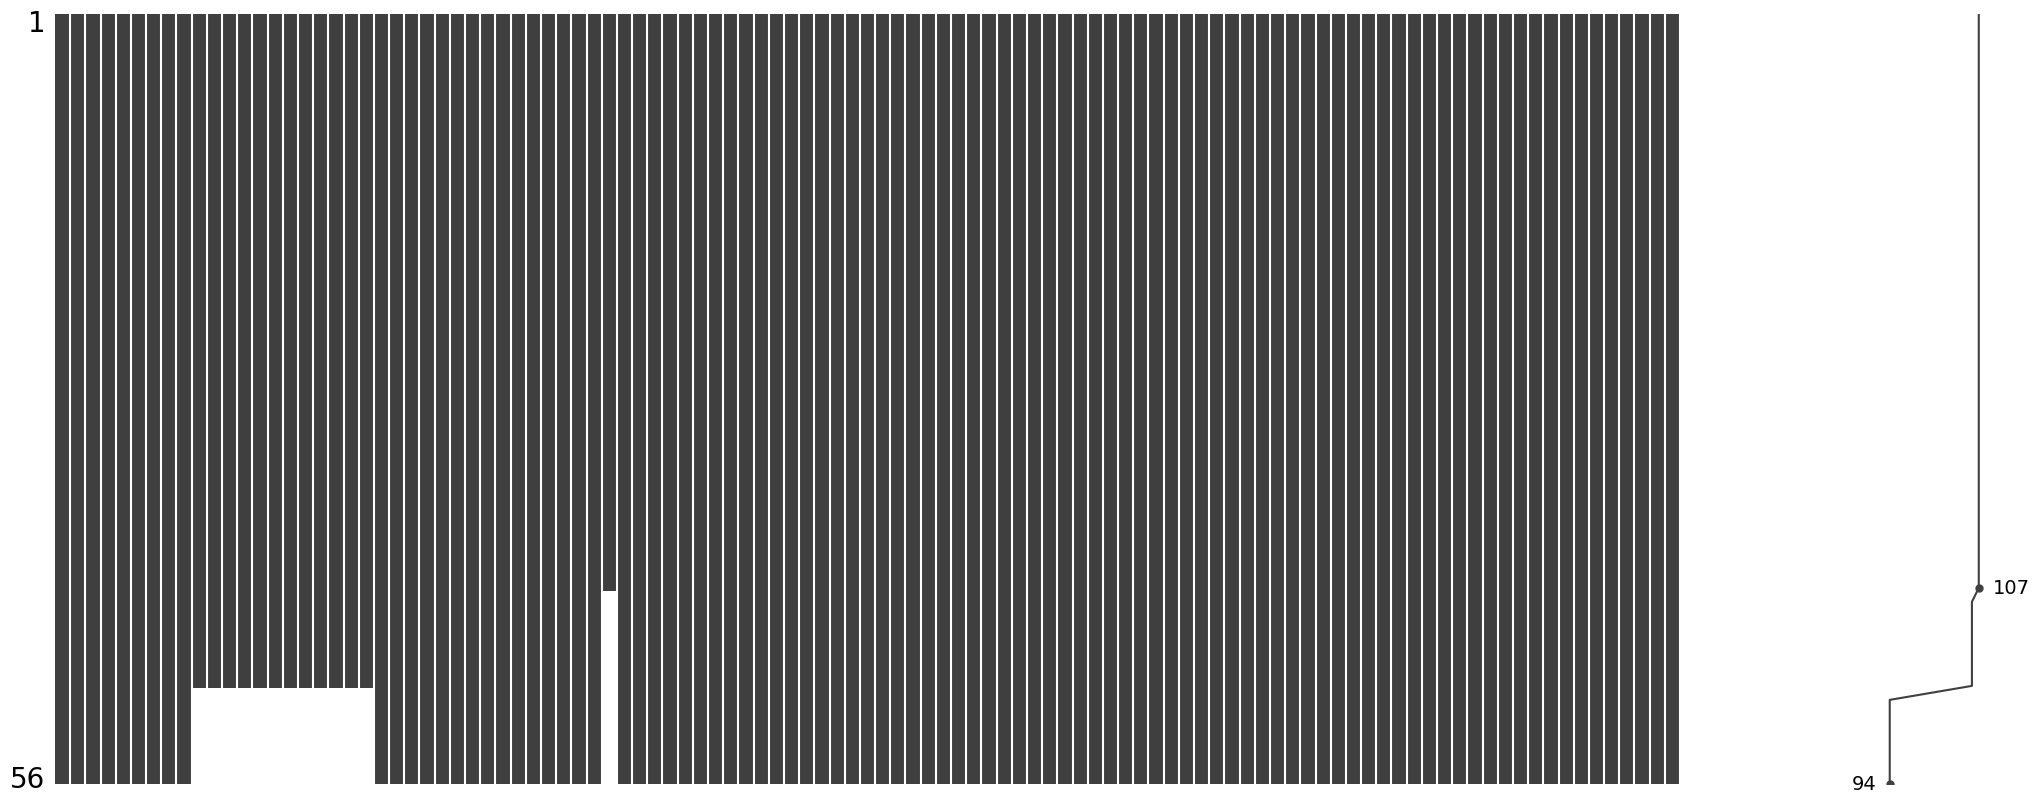

In [235]:
missingno.matrix(dataset)

In [236]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [237]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [238]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [239]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [240]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

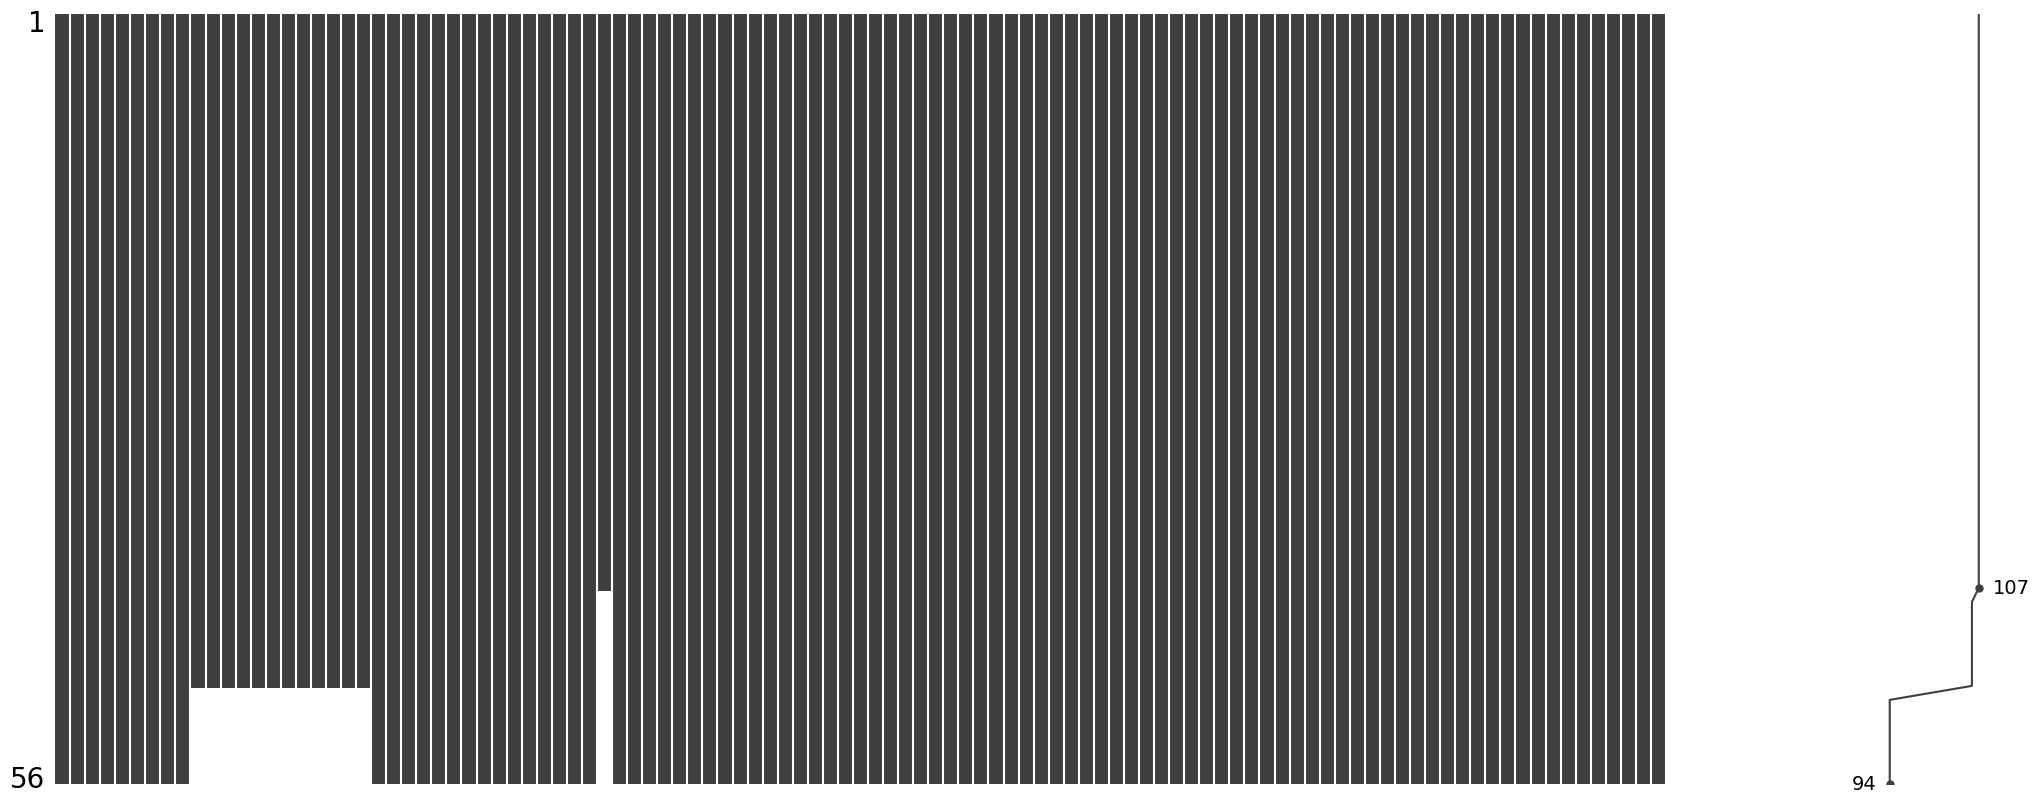

In [241]:
missingno.matrix(dataset)

In [242]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [243]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [244]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [245]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [246]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

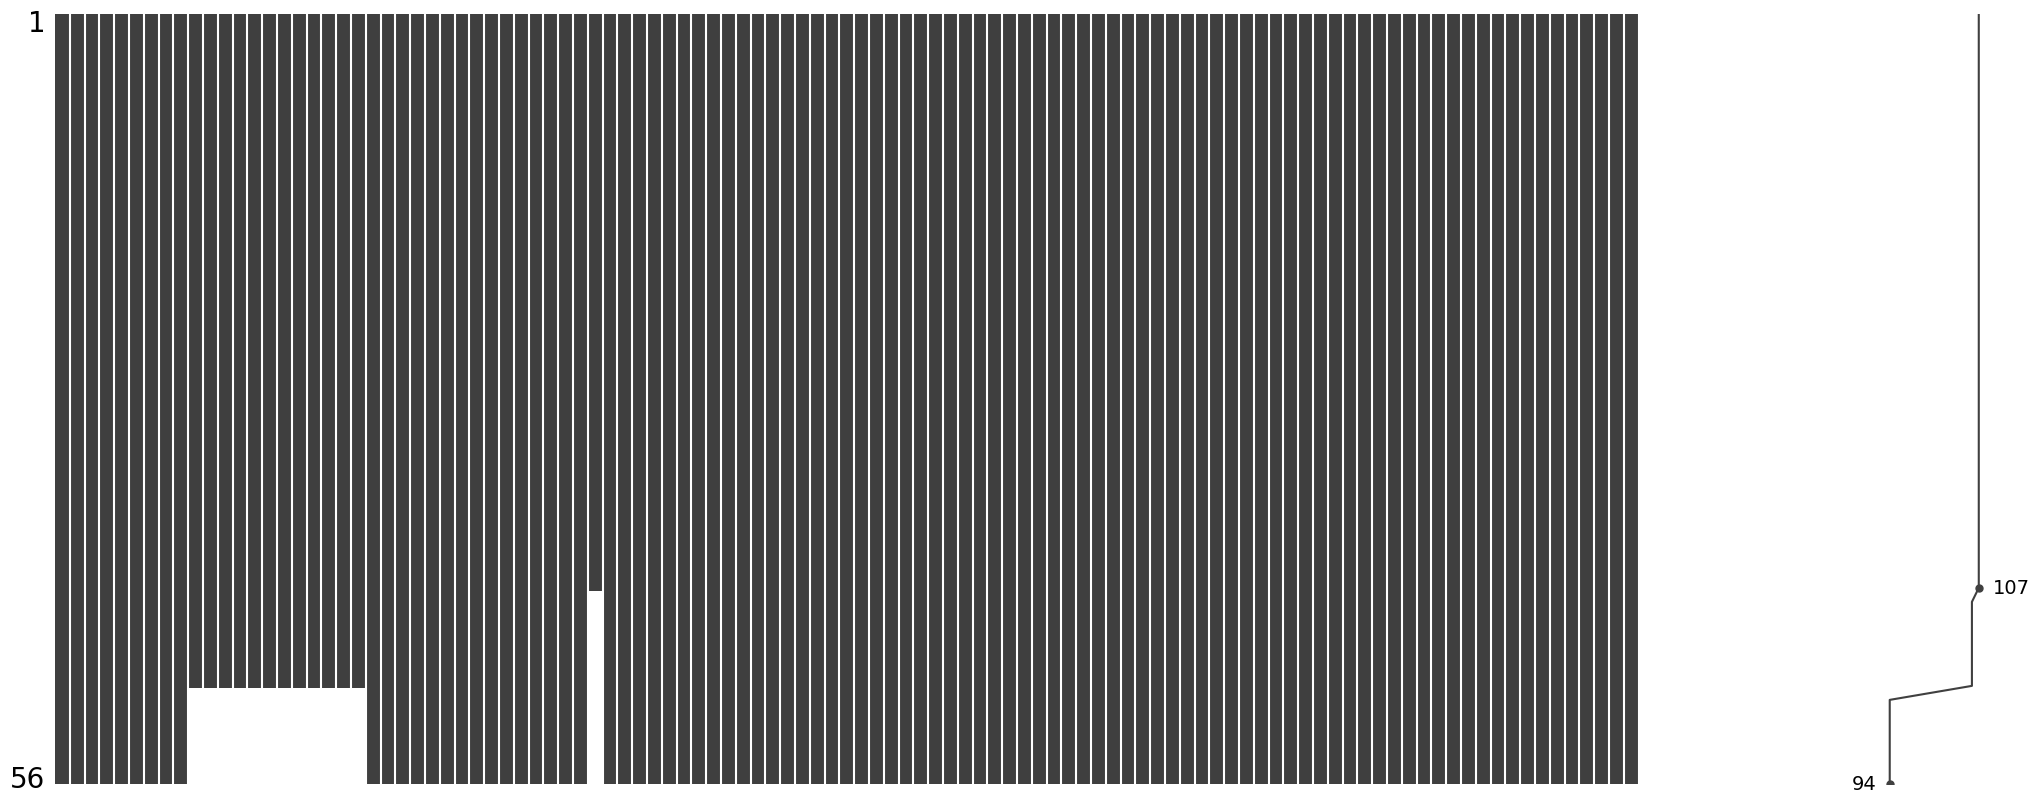

In [247]:
missingno.matrix(dataset)

In [248]:
missing = describe_dataframe(dataset)

In [249]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,100.000000
114,F_TOTAL,100.000000
115,MIO_EUR,100.000000
116,L_TOTAL,100.000000


In [250]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2024,0.253521,0.125124,-0.212388,-0.125124,0.245415,0.125427,-0.206581,-0.125427,0.050790,0.053745,0.052142,0.053745,7.495806,1.773059,4.634432,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,1.441790,7.228771,16.927973,43.819748,44.695487,1071.666667,34.569892,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487,0,16.937500,17.875000,44.687500,883.757198,37.000000,-3.000000,40.000000,16.500000,25.500000,25.500000,7.500000,346.000000,106.000000,0.000000,89.997104,240.000000,0.000000,0.000000,167.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2024,0.306417,0.063853,-0.265244,-0.063853,0.295632,0.060910,-0.256860,-0.060910,0.063070,0.069262,0.053936,0.069262,8.653382,1.898629,5.276006,8.653382,13.224235,15.961008,25.260156,1.898629,3.790065,6.232308,10.953750,5.276006,8.507150,11.096658,18.106953,2.784987,2.093208,27.402839,86.104488,86.334587,738.210938,23.813256,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587,0,18.500000,20.250000,46.022727,960.654539,41.000000,-3.000000,44.000000,12.166667,28.500000,28.500000,8.500000,451.000000,149.000000,0.000000,93.111415,300.000000,0.000000,0.000000,237.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2024,0.238070,-0.066854,-0.245603,0.066854,0.234567,-0.063794,-0.242235,0.063794,0.041735,0.044693,0.039558,0.044693,8.469299,0.607805,4.538552,8.469299,14.175660,16.577160,25.470522,0.607805,2.928861,5.633261,10.624087,4.538552,8.552260,11.105210,18.047304,1.618093,1.951708,10.855320,50.123795,50.160892,828.554348,26.727560,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51

In [251]:
dataset.reset_index(inplace=True, drop=True)

In [252]:
dataset['cases'].value_counts()

cases
0    56
Name: count, dtype: int64

In [253]:
dataset['cases'].sum()

0

In [254]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2024,0.253521,0.125124,-0.212388,-0.125124,0.245415,0.125427,-0.206581,-0.125427,0.050790,0.053745,0.052142,0.053745,7.495806,1.773059,4.634432,7.495806,11.969080,15.628925,25.236637,1.773059,3.472199,5.653668,10.723689,4.634432,7.720640,10.641296,17.980163,1.441790,7.228771,16.927973,43.819748,44.695487,1071.666667,34.569892,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,-3.513704,11.138148,44.695487,0,16.937500,17.875000,44.687500,883.757198,37.000000,-3.000000,40.000000,16.500000,25.500000,25.500000,7.500000,346.000000,106.000000,0.000000,89.997104,240.000000,0.000000,0.000000,167.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2024,0.306417,0.063853,-0.265244,-0.063853,0.295632,0.060910,-0.256860,-0.060910,0.063070,0.069262,0.053936,0.069262,8.653382,1.898629,5.276006,8.653382,13.224235,15.961008,25.260156,1.898629,3.790065,6.232308,10.953750,5.276006,8.507150,11.096658,18.106953,2.784987,2.093208,27.402839,86.104488,86.334587,738.210938,23.813256,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,36,30,12,12,1,6,6,2,-3.208750,14.712188,86.334587,0,18.500000,20.250000,46.022727,960.654539,41.000000,-3.000000,44.000000,12.166667,28.500000,28.500000,8.500000,451.000000,149.000000,0.000000,93.111415,300.000000,0.000000,0.000000,237.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2024,0.238070,-0.066854,-0.245603,0.066854,0.234567,-0.063794,-0.242235,0.063794,0.041735,0.044693,0.039558,0.044693,8.469299,0.607805,4.538552,8.469299,14.175660,16.577160,25.470522,0.607805,2.928861,5.633261,10.624087,4.538552,8.552260,11.105210,18.047304,1.618093,1.951708,10.855320,50.123795,50.160892,828.554348,26.727560,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51

In [255]:
cols = dataset.columns

In [256]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [257]:
len(cols)

118

In [258]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2024.csv", encoding = enc, index = False)
